# Notebook for Supervised ML: Classifying astronomical objects

Analyses based on paper: Clarke, A. O., Scaife, A. M. M., Greenhalgh, R. & Griguta, V. (2020). Identifying galaxies, quasars, and stars with machine learning: A new catalogue of classifications for 111 million SDSS sources without spectra. Astronomy & Astrophysics, 639, A84. https://doi.org/10.1051/0004-6361/201936770

Assisted by ChatGPT (30 Sept 2025 and 5 May 2026)

## Set up working tree and load packages

In [4]:
# load relevant packages:
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    f1_score,
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.base import clone
from sklearn.exceptions import ConvergenceWarning


import numpy as np
import pickle
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt

import warnings

# load data:
(tsne_subsample,tsne_subsample_classes) = pickle.load( open( "Dataset_galaxies_quasars_stars/subdf_unsupervised.pickle", "rb" ))

In [6]:
print( np.unique( tsne_subsample_classes ))
for o in ['STAR','GALAXY','QSO']:
    print( o )
    print( np.round( tsne_subsample[ np.where(tsne_subsample_classes==o)[0][:2] ], 3 ) )

['GALAXY' 'QSO' 'STAR']
STAR
[[2.1529e+01 1.8571e+01 1.7199e+01 1.6525e+01 1.6147e+01 1.4014e+01
  1.4036e+01 1.3286e+01 9.1180e+00 3.0000e-03]
 [1.9190e+01 1.7982e+01 1.7467e+01 1.7235e+01 1.7123e+01 1.5295e+01
  1.5094e+01 1.2837e+01 9.1740e+00 5.0000e-03]]
GALAXY
[[21.36  20.022 19.495 19.128 18.878 14.604 14.425 11.079  8.945  2.411]
 [22.783 22.479 21.295 20.391 22.827 13.546 13.588 11.999  9.046  0.628]]
QSO
[[2.0617e+01 2.0084e+01 2.0109e+01 2.0126e+01 1.9884e+01 1.7075e+01
  1.5981e+01 1.3118e+01 8.8840e+00 1.4000e-02]
 [1.9939e+01 1.9849e+01 1.9543e+01 1.9615e+01 1.9629e+01 1.5371e+01
  1.4206e+01 1.1351e+01 9.3030e+00 7.0000e-03]]


In [8]:
# --------------------- Set up data for crossvalidation ---------------------

# Splitting the dataset into train and test
# (set random_state to make split reproducible)
X_train, X_test, y_train, y_test = train_test_split(tsne_subsample,
                                                    tsne_subsample_classes,
                                                    test_size=0.4,
                                                    random_state=42)

# generate test and validation:
X_val, X_test, y_val, y_test = train_test_split(X_test,
                                                    y_test,
                                                    test_size=0.5,
                                                    random_state=42)

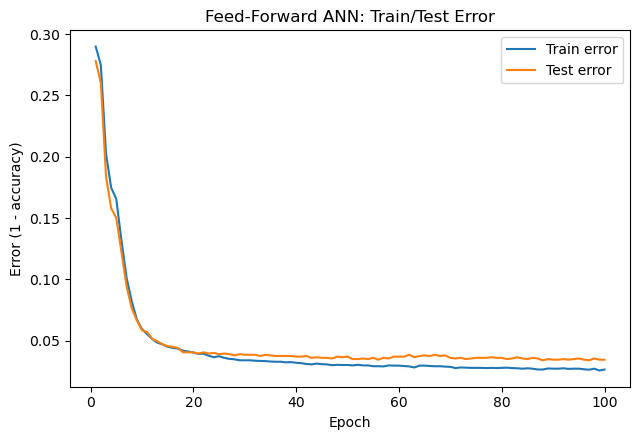

Final Train Error: 0.026
Final Test Error : 0.034


In [10]:
# --- Define MLP ---
mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),  # two hidden layers
    activation='relu',
    solver='adam',
    alpha=1e-4,
    batch_size=256,
    learning_rate_init=1e-3,
    max_iter=1,         # we will control epochs manually
    warm_start=False,
    shuffle=True,
    random_state=42,
    verbose=False
)

n_epochs = 100
train_err, test_err = [], []

for epoch in range(n_epochs):
    if epoch == 0:
        mlp.partial_fit(X_train, y_train, classes=np.unique(y_train))
    else:
        mlp.partial_fit(X_train, y_train)

    # Errors
    train_acc = accuracy_score(y_train, mlp.predict(X_train))
    test_acc  = accuracy_score(y_test,  mlp.predict(X_test))
    train_err.append(1.0 - train_acc)
    test_err.append(1.0 - test_acc)

# --- Plot train/test error vs. epochs ---
plt.figure(figsize=(6.5, 4.5))
plt.plot(range(1, n_epochs+1), train_err, label="Train error")
plt.plot(range(1, n_epochs+1), test_err, label="Test error")
plt.xlabel("Epoch")
plt.ylabel("Error (1 - accuracy)")
plt.title("Feed-Forward ANN: Train/Test Error")
plt.legend()
plt.tight_layout()
plt.savefig("ann_train_test_error.png", dpi=200, bbox_inches="tight")
plt.show()

print("Final Train Error: {:.3f}".format(train_err[-1]))
print("Final Test Error : {:.3f}".format(test_err[-1]))

In [11]:
# --------------------- Final test-set predictions ---------------------
# This cell fixes the common failure in the original notebook: y_pred must be
# explicitly defined before it can be passed to classification_report.
#
# The test set is used here only after training. This preserves the usual
# train/validation/test logic: train the model on X_train, use validation data
# for tuning or early stopping if desired, and reserve X_test for the final
# performance report.

y_pred = mlp.predict(X_test)

test_accuracy = accuracy_score(y_test, y_pred)
test_balanced_accuracy = balanced_accuracy_score(y_test, y_pred)
test_macro_f1 = f1_score(y_test, y_pred, average="macro")

print(f"Test accuracy:          {test_accuracy:.3f}")
print(f"Balanced test accuracy: {test_balanced_accuracy:.3f}")
print(f"Macro F1-score:         {test_macro_f1:.3f}")
print()
print(classification_report(y_test, y_pred))

Test accuracy:          0.966
Balanced test accuracy: 0.929
Macro F1-score:         0.942

              precision    recall  f1-score   support

      GALAXY       0.97      0.99      0.98      1444
         QSO       0.93      0.88      0.90       240
        STAR       0.98      0.92      0.95       316

    accuracy                           0.97      2000
   macro avg       0.96      0.93      0.94      2000
weighted avg       0.97      0.97      0.97      2000




## Post-hoc validation of the astronomical classifier

The training curve and classification report are useful first checks, but they do not yet explain *what* the model has learned. The following two validation procedures make the notebook more physics-oriented and address the reviewer comments.

**Procedure 1** uses a confusion matrix and per-class metrics to ask which astronomical populations are confused with each other. This matters because the classes are not equally easy: galaxies are often spatially extended, stars are point-like, and quasars can look point-like while having colors that overlap with stars or compact galaxies.

**Procedure 2** uses feature ablation. The model is retrained after removing physically meaningful feature groups, such as the morphology feature `resolved` or the infrared WISE bands. A performance drop after removing a feature group indicates that the removed measurements contain useful astrophysical information for the classifier.



### Validation procedure 1: confusion matrix and class-wise performance

Accuracy alone can be misleading for imbalanced catalogues. A classifier can obtain a high overall accuracy while still performing poorly on a minority class such as quasars. The confusion matrix shows the direction of the errors: for example, whether quasars are mostly mistaken for stars or for galaxies. This connects the numerical validation to astrophysics, because different error types have different physical interpretations.

The normalized confusion matrix below is read row-wise: each row corresponds to the true class, and each entry shows the fraction of objects of that true class assigned to each predicted class. A strong classifier has large diagonal values for all three classes, not only for the majority class.


Validation procedure 1: confusion matrix and class-wise performance
  Test accuracy:          0.966
  Balanced test accuracy: 0.929
  Macro F1-score:         0.942

Classification report:
              precision    recall  f1-score   support

      GALAXY       0.97      0.99      0.98      1444
         QSO       0.93      0.88      0.90       240
        STAR       0.98      0.92      0.95       316

    accuracy                           0.97      2000
   macro avg       0.96      0.93      0.94      2000
weighted avg       0.97      0.97      0.97      2000



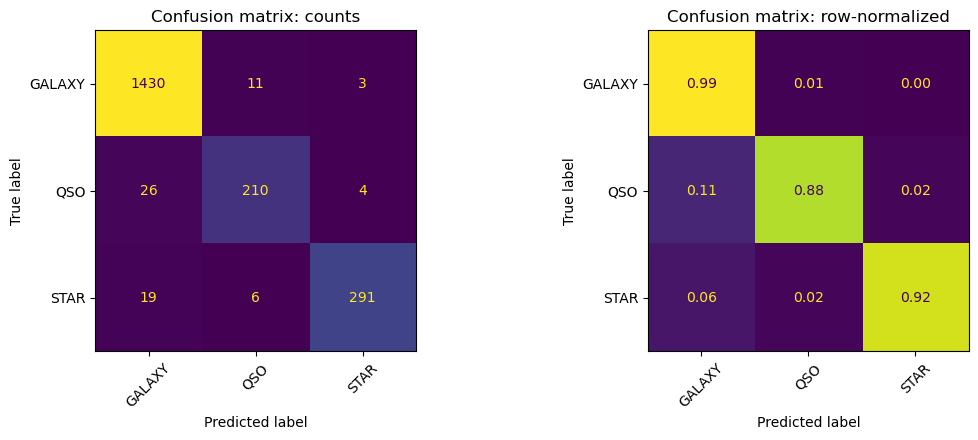

,precision,recall,f1-score,support
GALAXY,0.969492,0.990305,0.979788,1444.0000
QSO,0.925110,0.875000,0.899358,240.0000
STAR,0.976510,0.920886,0.947883,316.0000
accuracy,0.965500,0.965500,0.965500,0.9655
macro avg,0.957037,0.928730,0.942343,2000.0000
weighted avg,0.965275,0.965500,0.965095,2000.0000


In [14]:
# --------------------- Validation procedure 1 ---------------------
# Confusion matrix and class-wise performance diagnostics.
#
# Required variables from earlier cells:
# - X_test, y_test: held-out test data
# - mlp: trained ANN classifier
# - y_pred: predicted class labels on the test set

import os
import numpy as np
import matplotlib.pyplot as plt

# Robustly define y_pred in case this validation section is run independently.
if "y_pred" not in globals():
    y_pred = mlp.predict(X_test)

class_labels = np.array(sorted(np.unique(np.concatenate([np.asarray(y_test), np.asarray(y_pred)]))))

cm_counts = confusion_matrix(y_test, y_pred, labels=class_labels)
cm_norm = confusion_matrix(y_test, y_pred, labels=class_labels, normalize="true")

print("Validation procedure 1: confusion matrix and class-wise performance")
print(f"  Test accuracy:          {accuracy_score(y_test, y_pred):.3f}")
print(f"  Balanced test accuracy: {balanced_accuracy_score(y_test, y_pred):.3f}")
print(f"  Macro F1-score:         {f1_score(y_test, y_pred, average='macro'):.3f}")
print()
print("Classification report:")
print(classification_report(y_test, y_pred, labels=class_labels))

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.5))

ConfusionMatrixDisplay(cm_counts, display_labels=class_labels).plot(
    ax=axes[0], values_format="d", colorbar=False
)
axes[0].set_title("Confusion matrix: counts")
axes[0].tick_params(axis="x", rotation=45)

ConfusionMatrixDisplay(cm_norm, display_labels=class_labels).plot(
    ax=axes[1], values_format=".2f", colorbar=False
)
axes[1].set_title("Confusion matrix: row-normalized")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
os.makedirs("img", exist_ok=True)
fig.savefig("img/ann_confusion_matrix_counts_and_normalized.png", dpi=300, bbox_inches="tight")
plt.show()

# Store a compact table for manuscript-style reporting.
report_dict = classification_report(y_test, y_pred, labels=class_labels, output_dict=True)
validation1_summary = pd.DataFrame(report_dict).T
validation1_summary



**Interpretation guide.** A good result is not only a high accuracy, but also a high **macro F1-score** and a high **balanced accuracy**. These metrics weight the classes more evenly than ordinary accuracy and therefore make the minority classes visible. If one off-diagonal entry is large, inspect it physically: star--quasar confusion may indicate overlapping point-source colors, while galaxy--star confusion may indicate weak or noisy morphology information.



### Validation procedure 2: feature-ablation analysis

Feature ablation asks whether the classifier relies on measurements with clear astrophysical meaning. The full model is compared with models trained after removing feature groups:

- **without `resolved`**: tests how important morphology is for separating point-like and extended sources;
- **without WISE bands**: tests how much the infrared measurements contribute, especially for quasars and other sources with non-stellar emission;
- **optical-only plus `resolved`**: keeps the SDSS optical bands and morphology but removes the infrared view of the spectral energy distribution.

A large performance drop after removing a feature group indicates that this group carries important information. This is a validation of the physical interpretation, not just of the model accuracy.


Validation procedure 2: feature-ablation analysis
        feature setting  n_features  accuracy  balanced_accuracy  macro_f1  accuracy_drop_vs_full  balanced_accuracy_drop_vs_full  macro_f1_drop_vs_full
           all features          10     0.969              0.944     0.948                  0.000                           0.000                  0.000
       without resolved           9     0.965              0.933     0.942                  0.004                           0.011                  0.006
     without WISE bands           6     0.961              0.927     0.930                  0.008                           0.017                  0.018
optical + resolved only           6     0.961              0.927     0.930                  0.008                           0.017                  0.018


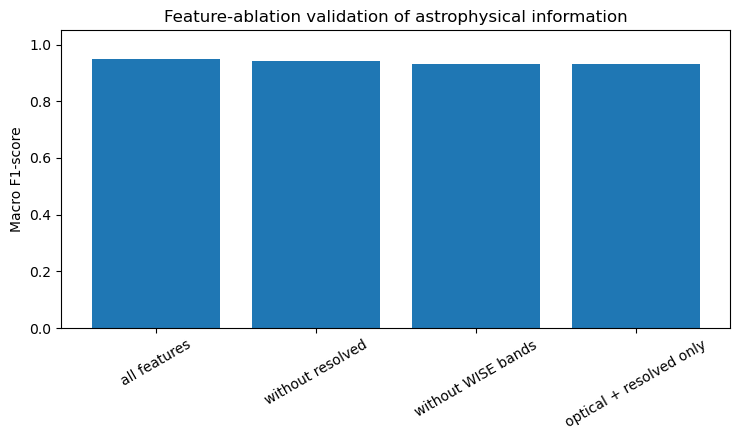

,feature setting,n_features,accuracy,balanced_accuracy,macro_f1,weighted_f1,features used,accuracy_drop_vs_full,balanced_accuracy_drop_vs_full,macro_f1_drop_vs_full,weighted_f1_drop_vs_full
0,all features,10,0.9690,0.944221,0.947982,0.968912,"u, g, r, i, z, w1, w2, w3, w4, resolved",0.0000,0.000000,0.000000,0.000000
1,without resolved,9,0.9650,0.933421,0.941562,0.964609,"u, g, r, i, z, w1, w2, w3, w4",0.0040,0.010799,0.006420,0.004304
2,without WISE bands,6,0.9605,0.926934,0.930359,0.960436,"u, g, r, i, z, resolved",0.0085,0.017287,0.017623,0.008476
3,optical + resolved only,6,0.9605,0.926934,0.930359,0.960436,"u, g, r, i, z, resolved",0.0085,0.017287,0.017623,0.008476


In [20]:
# --------------------- Validation procedure 2 ---------------------
# Feature-ablation analysis.
#
# The goal is to connect performance to astrophysical information in the input
# features. We retrain comparable ANN classifiers after removing physically
# meaningful feature groups and compare their test-set performance.

# Expected feature order from the manuscript and Clarke et al.-style data set.
# If your data set uses a different order, adjust this list accordingly.
feature_names = [
    "u", "g", "r", "i", "z",       # SDSS optical bands
    "w1", "w2", "w3", "w4",       # WISE infrared bands
    "resolved"                      # morphology / extension proxy
]

n_features = np.asarray(X_train).shape[1]
if n_features != len(feature_names):
    feature_names = [f"feature_{j}" for j in range(n_features)]
    print(
        f"Warning: expected 10 features, but found {n_features}. "
        "Using generic feature names. Please adjust feature_names if needed."
    )

feature_names = np.array(feature_names)

# Define feature groups robustly by name when possible.
def indices_not_in(remove_names):
    remove_names = set(remove_names)
    return np.array([j for j, name in enumerate(feature_names) if name not in remove_names], dtype=int)

wise_names = [name for name in feature_names if name in {"w1", "w2", "w3", "w4"}]
resolved_names = [name for name in feature_names if name == "resolved"]
optical_names = [name for name in feature_names if name in {"u", "g", "r", "i", "z"}]

ablation_sets = {
    "all features": np.arange(n_features),
}

if resolved_names:
    ablation_sets["without resolved"] = indices_not_in(resolved_names)
if wise_names:
    ablation_sets["without WISE bands"] = indices_not_in(wise_names)
if optical_names and resolved_names:
    keep = [name for name in feature_names if name in set(optical_names + resolved_names)]
    ablation_sets["optical + resolved only"] = np.array([j for j, name in enumerate(feature_names) if name in keep], dtype=int)

# Use a fresh, comparable MLP for each ablation. StandardScaler is included
# because dense neural networks generally train more stably when numerical
# features are on comparable scales.
def make_validation_model(random_state=42):
    return make_pipeline(
        StandardScaler(),
        MLPClassifier(
            hidden_layer_sizes=(128, 64),
            activation="relu",
            solver="adam",
            alpha=1e-4,
            batch_size=256,
            learning_rate_init=1e-3,
            max_iter=300,
            early_stopping=True,
            validation_fraction=0.15,
            n_iter_no_change=20,
            random_state=random_state,
            verbose=False
        )
    )

rows = []
with warnings.catch_warnings():
    warnings.simplefilter("ignore", ConvergenceWarning)
    for setting, idx in ablation_sets.items():
        model = make_validation_model(random_state=42)
        model.fit(np.asarray(X_train)[:, idx], y_train)
        pred = model.predict(np.asarray(X_test)[:, idx])
        rows.append({
            "feature setting": setting,
            "n_features": len(idx),
            "accuracy": accuracy_score(y_test, pred),
            "balanced_accuracy": balanced_accuracy_score(y_test, pred),
            "macro_f1": f1_score(y_test, pred, average="macro"),
            "weighted_f1": f1_score(y_test, pred, average="weighted"),
            "features used": ", ".join(feature_names[idx])
        })

ablation_results = pd.DataFrame(rows).sort_values("macro_f1", ascending=False).reset_index(drop=True)

# Compute performance drops relative to the full feature set.
full_row = ablation_results[ablation_results["feature setting"] == "all features"].iloc[0]
for metric in ["accuracy", "balanced_accuracy", "macro_f1", "weighted_f1"]:
    ablation_results[f"{metric}_drop_vs_full"] = full_row[metric] - ablation_results[metric]

print("Validation procedure 2: feature-ablation analysis")
display_cols = [
    "feature setting", "n_features", "accuracy", "balanced_accuracy", "macro_f1",
    "accuracy_drop_vs_full", "balanced_accuracy_drop_vs_full", "macro_f1_drop_vs_full"
]
print(ablation_results[display_cols].to_string(index=False, float_format=lambda x: f"{x:.3f}"))

# Plot macro-F1 because it treats galaxies, quasars, and stars equally.
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.bar(ablation_results["feature setting"], ablation_results["macro_f1"])
ax.set_ylabel("Macro F1-score")
ax.set_title("Feature-ablation validation of astrophysical information")
ax.set_ylim(0, 1.05)
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
fig.savefig("img/ann_feature_ablation_macro_f1.png", dpi=300, bbox_inches="tight")
plt.show()

ablation_results



**Interpretation guide.** If removing `resolved` reduces macro F1 or balanced accuracy, the classifier is using morphology to distinguish point-like sources from extended galaxies. If removing the WISE bands reduces performance, infrared colors are contributing information about the source spectral energy distribution. A small drop does not mean the feature group is physically irrelevant; correlated features can partly replace one another. The ablation should therefore be interpreted as an instructional diagnostic rather than a proof of causal importance.


## Optional extension: model complexity and double descent

This section is optional and computationally heavier. It is useful for advanced discussion of model capacity, but it is not needed for the two validation procedures above.

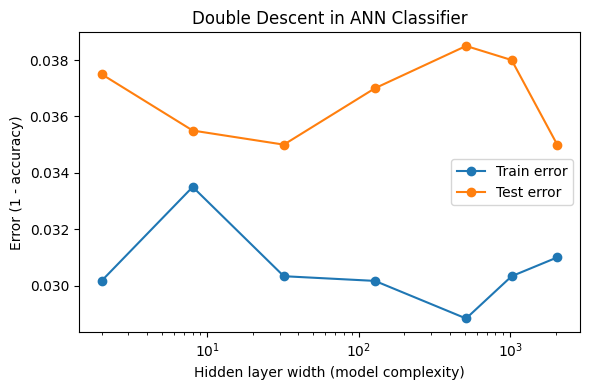

In [8]:
widths = [2, 8, 32, 128, 512, 1024, 2**11]
train_err, test_err = [], []

for w in widths:
    mlp = MLPClassifier(
        hidden_layer_sizes=(w,),   # single hidden layer with variable width
        activation='relu',
        solver='adam',
        max_iter=500,
        random_state=42
    )
    mlp.fit(X_train, y_train)
    train_err.append(1 - accuracy_score(y_train, mlp.predict(X_train)))
    test_err.append(1 - accuracy_score(y_test, mlp.predict(X_test)))

plt.figure(figsize=(6,4))
plt.plot(widths, train_err, marker='o', label='Train error')
plt.plot(widths, test_err, marker='o', label='Test error')
plt.xscale('log')
plt.xlabel("Hidden layer width (model complexity)")
plt.ylabel("Error (1 - accuracy)")
plt.title("Double Descent in ANN Classifier")
plt.legend()
plt.tight_layout()
plt.show()

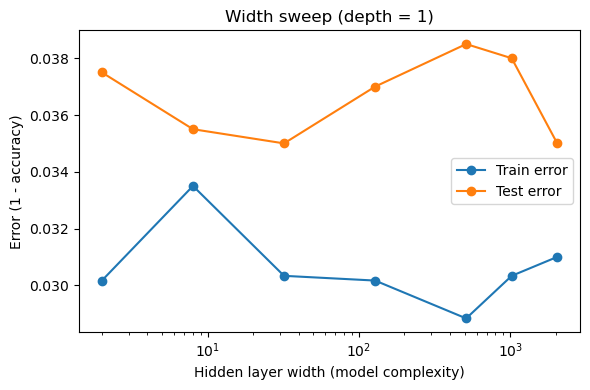

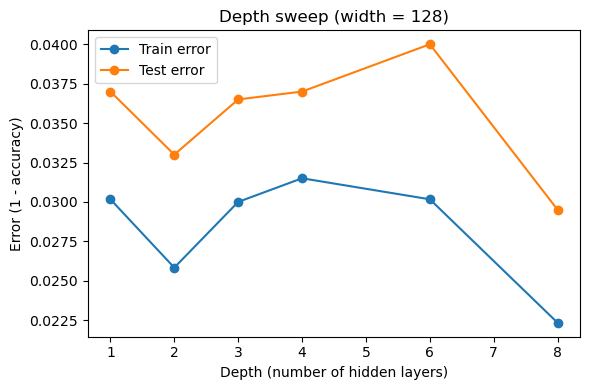

depth= 1, width=   2 -> train_err=0.030, test_err=0.037
depth= 1, width=   8 -> train_err=0.033, test_err=0.035
depth= 1, width=  32 -> train_err=0.030, test_err=0.035
depth= 1, width= 128 -> train_err=0.030, test_err=0.037
depth= 1, width= 512 -> train_err=0.029, test_err=0.038
depth= 1, width=1024 -> train_err=0.030, test_err=0.038
depth= 2, width=   2 -> train_err=0.290, test_err=0.278
depth= 2, width=   8 -> train_err=0.048, test_err=0.059
depth= 2, width=  32 -> train_err=0.031, test_err=0.042
depth= 2, width= 128 -> train_err=0.026, test_err=0.033
depth= 2, width= 512 -> train_err=0.030, test_err=0.037
depth= 2, width=1024 -> train_err=0.029, test_err=0.037
depth= 3, width=   2 -> train_err=0.045, test_err=0.056
depth= 3, width=   8 -> train_err=0.031, test_err=0.039
depth= 3, width=  32 -> train_err=0.032, test_err=0.037
depth= 3, width= 128 -> train_err=0.030, test_err=0.036


In [ ]:
# ----------------------------
# 1) Width sweep (depth = 1)
# ----------------------------
widths = [2, 8, 32, 128, 512, 1024, 2**11]  # same as your list
train_err_w, test_err_w = [], []

for w in widths:
    mlp = MLPClassifier(
        hidden_layer_sizes=(w,),   # single hidden layer
        activation='relu',
        solver='adam',
        max_iter=500,
        random_state=42,
        shuffle=True,
        verbose=False
    )
    mlp.fit(X_train, y_train)
    train_err_w.append(1.0 - accuracy_score(y_train, mlp.predict(X_train)))
    test_err_w.append(1.0 - accuracy_score(y_test,  mlp.predict(X_test)))

plt.figure(figsize=(6,4))
plt.plot(widths, train_err_w, marker='o', label='Train error')
plt.plot(widths, test_err_w, marker='o', label='Test error')
plt.xscale('log')
plt.xlabel("Hidden layer width (model complexity)")
plt.ylabel("Error (1 - accuracy)")
plt.title("Width sweep (depth = 1)")
plt.legend()
plt.tight_layout()
plt.show()

# ----------------------------
# 2) Depth sweep (fixed width)
# ----------------------------
fixed_width = 128
depths = [1, 2, 3, 4, 6, 8]
train_err_d, test_err_d = [], []

for d in depths:
    hidden = tuple([fixed_width]*d)
    mlp = MLPClassifier(
        hidden_layer_sizes=hidden,
        activation='relu',
        solver='adam',
        max_iter=500,
        random_state=42,
        shuffle=True,
        verbose=False
    )
    mlp.fit(X_train, y_train)
    train_err_d.append(1.0 - accuracy_score(y_train, mlp.predict(X_train)))
    test_err_d.append(1.0 - accuracy_score(y_test,  mlp.predict(X_test)))

plt.figure(figsize=(6,4))
plt.plot(depths, train_err_d, marker='o', label='Train error')
plt.plot(depths, test_err_d, marker='o', label='Test error')
plt.xlabel("Depth (number of hidden layers)")
plt.ylabel("Error (1 - accuracy)")
plt.title(f"Depth sweep (width = {fixed_width})")
plt.legend()
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 3) Joint sweep: width × depth grid + contour/heatmaps
# ---------------------------------------------------------
# NOTE: Very large widths x deep nets can be slow. Adjust as needed.
grid_widths = [2, 8, 32, 128, 512, 1024]   # you can include 2048 if runtime allows
grid_depths = [1, 2, 3, 4, 6]              # extend if you want

W = len(grid_widths)
D = len(grid_depths)
err_train = np.zeros((D, W))
err_test  = np.zeros((D, W))

for i, d in enumerate(grid_depths):
    for j, w in enumerate(grid_widths):
        hidden = tuple([w]*d)
        mlp = MLPClassifier(
            hidden_layer_sizes=hidden,
            activation='relu',
            solver='adam',
            max_iter=500,
            random_state=42,
            shuffle=True,
            verbose=False
        )
        mlp.fit(X_train, y_train)
        err_train[i, j] = 1.0 - accuracy_score(y_train, mlp.predict(X_train))
        err_test[i, j]  = 1.0 - accuracy_score(y_test,  mlp.predict(X_test))
        print(f"depth={d:>2}, width={w:>4} -> train_err={err_train[i,j]:.3f}, test_err={err_test[i,j]:.3f}")

# Plot as heatmaps with contours (x=width, y=depth)
width_ticks = np.arange(W)
depth_ticks = np.arange(D)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
# Train error
im0 = axes[0].imshow(err_train, origin='lower', aspect='auto', cmap='viridis')
cs0 = axes[0].contour(err_train, colors='w', linewidths=0.8, levels=6)
axes[0].clabel(cs0, inline=True, fontsize=8)
axes[0].set_xticks(width_ticks); axes[0].set_xticklabels([str(w) for w in grid_widths], rotation=45)
axes[0].set_yticks(depth_ticks); axes[0].set_yticklabels([str(d) for d in grid_depths])
axes[0].set_xlabel("Width (neurons per hidden layer)")
axes[0].set_ylabel("Depth (number of hidden layers)")
axes[0].set_title("Train error (1 - accuracy)")
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

# Test error
im1 = axes[1].imshow(err_test, origin='lower', aspect='auto', cmap='viridis')
cs1 = axes[1].contour(err_test, colors='w', linewidths=0.8, levels=6)
axes[1].clabel(cs1, inline=True, fontsize=8)
axes[1].set_xticks(width_ticks); axes[1].set_xticklabels([str(w) for w in grid_widths], rotation=45)
axes[1].set_yticks(depth_ticks); axes[1].set_yticklabels([str(d) for d in grid_depths])
axes[1].set_xlabel("Width (neurons per hidden layer)")
axes[1].set_ylabel("Depth (number of hidden layers)")
axes[1].set_title("Test error (1 - accuracy)")
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()